# NB-07 · BYOL + SegFormer-B0
## Brain Tumour MRI Binary Semantic Segmentation from COCO Polygons

**Course:** CSE 438: Digital Image Processing  
**Course Instructor:** Dr Md Rifat Ahmmad Rashid  
**Department:** Department of Computer Science and Engineering  
**Institution:** East West University (EWU)

---

### Learning objective

This notebook studies self-supervised feature learning for medical-image segmentation through two connected stages:

1. **Bootstrap Your Own Latent (BYOL) pretraining:** a SegFormer MiT-B0 encoder learns consistent representations from two augmented views of each MRI without using tumour masks.
2. **SegFormer-B0 fine-tuning:** the same BYOL-trained MiT-B0 encoder is transferred directly into `SegformerForSemanticSegmentation` for binary tumour segmentation.

The COCO polygon annotations are converted into semantic masks using the following label convention:

\[
0 = \text{background}, \qquad 1 = \text{tumour region}.
\]

### Methodological rule

The downstream architecture is SegFormer; therefore, BYOL pretraining is applied to the **MiT-B0 encoder itself**. A ResNet or other unrelated encoder is not used for transfer.

### Computational safety

The notebook uses standard contiguous tensors only. A CUDA kernel test is executed before training. AMP is enabled only if that test succeeds; otherwise, execution automatically falls back to CPU. The BYOL similarity loss is evaluated explicitly in `float32` for numerical stability.

## BYOL-to-SegFormer pipeline

For two augmented views \(v_1\) and \(v_2\) of the same MRI, BYOL uses an **online network** and a **target network**. The online branch contains an encoder, projector, and predictor. The target branch contains an encoder and projector updated through an exponential moving average (EMA), not by gradient descent.

\[
\mathcal{L}_{\text{BYOL}} =
\frac{1}{2}\left[
2-2\cos\!\left(q_{\theta}(v_1), z_{\xi}(v_2)\right)
+
2-2\cos\!\left(q_{\theta}(v_2), z_{\xi}(v_1)\right)
\right]
\]

\[
\xi \leftarrow \tau\xi + (1-\tau)\theta
\]

After pretraining, the trained online MiT-B0 encoder is copied into the SegFormer segmentation model and fine-tuned with merged binary tumour masks.

In [1]:
# ============================================================
# 1. Imports, paths, experiment settings, and reproducibility
# ============================================================

from pathlib import Path
from contextlib import nullcontext
import copy
import json
import math
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Rectangle
from PIL import Image, ImageDraw

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms as T
from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode

from transformers import SegformerConfig, SegformerModel, SegformerForSemanticSegmentation

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

from tqdm.auto import tqdm

warnings.filterwarnings('ignore', category=UserWarning)

# ------------------------------------------------------------
# Required Kaggle dataset path for the CSE 438 experiment.
# ------------------------------------------------------------
DATA_ROOT = Path('/kaggle/input/datasets/pkdarabi/brain-tumor-image-dataset-semantic-segmentation')

# ------------------------------------------------------------
# All outputs are written under /kaggle/working/.
# ------------------------------------------------------------
OUTPUT_DIR = Path('/kaggle/working/byol_segformer_brain_tumour')
FIGURE_DIR = OUTPUT_DIR / 'figures'
CHECKPOINT_DIR = OUTPUT_DIR / 'checkpoints'
METRIC_DIR = OUTPUT_DIR / 'metrics'
for directory in [OUTPUT_DIR, FIGURE_DIR, CHECKPOINT_DIR, METRIC_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Training and architectural settings.
# ------------------------------------------------------------
SEED = 438
IMAGE_SIZE = 224
NUM_CLASSES = 2
BYOL_EPOCHS = 10
SEGMENTATION_EPOCHS = 10
NUM_WORKERS = 2

MIT_MODEL_ID = 'nvidia/mit-b0'
LOAD_PRETRAINED_MIT_WHEN_AVAILABLE = True

BYOL_PROJECTION_DIM = 256
BYOL_HIDDEN_DIM = 1024
BYOL_EMA_BASE = 0.996
BYOL_LR = 2e-4
SEGMENTATION_LR = 2e-4
WEIGHT_DECAY = 1e-4

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
NORMALISE = T.Normalize(IMAGENET_MEAN, IMAGENET_STD)

def seed_everything(seed=SEED):
    '''Fix pseudo-random choices so that demonstrations can be repeated.'''
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        try:
            torch.cuda.manual_seed_all(seed)
        except Exception:
            pass

seed_everything()
print(f'Dataset root: {DATA_ROOT}')
print(f'Output directory: {OUTPUT_DIR}')
print(f'Torch version: {torch.__version__}')

Dataset root: /kaggle/input/datasets/pkdarabi/brain-tumor-image-dataset-semantic-segmentation
Output directory: /kaggle/working/byol_segformer_brain_tumour
Torch version: 2.10.0+cu128


In [2]:
# ============================================================
# 2. CUDA execution probe and conditional mixed precision
# ============================================================

def select_safe_device():
    '''
    Kaggle may expose a CUDA device even when the installed Torch binary cannot
    execute kernels on that GPU. This test runs an actual forward and backward
    convolution before GPU training is accepted.
    '''
    if not torch.cuda.is_available():
        print('CUDA is unavailable. CPU execution selected; AMP is disabled.')
        return torch.device('cpu'), False

    try:
        probe_input = torch.randn(2, 3, 32, 32, device='cuda', requires_grad=True)
        probe_layer = nn.Conv2d(3, 8, kernel_size=3, padding=1).to('cuda')
        probe_loss = probe_layer(probe_input).square().mean()
        probe_loss.backward()
        torch.cuda.synchronize()
        print(f'CUDA probe passed on: {torch.cuda.get_device_name(0)}')
        print('CUDA execution selected; AMP is enabled for forward passes.')
        return torch.device('cuda'), True
    except Exception as error:
        print('CUDA is visible but the kernel execution test failed.')
        print(f'Diagnostic: {type(error).__name__}: {error}')
        print('CPU fallback selected; AMP is disabled.')
        return torch.device('cpu'), False

DEVICE, AMP_ENABLED = select_safe_device()

def autocast_context():
    '''Enable automatic mixed precision only after a successful CUDA probe.'''
    if not AMP_ENABLED:
        return nullcontext()
    try:
        return torch.amp.autocast(device_type='cuda', dtype=torch.float16, enabled=True)
    except AttributeError:
        return torch.cuda.amp.autocast(dtype=torch.float16, enabled=True)

def float32_loss_context(tensor):
    '''Disable AMP locally while the BYOL cosine loss is computed.'''
    if not tensor.is_cuda:
        return nullcontext()
    try:
        return torch.amp.autocast(device_type='cuda', enabled=False)
    except AttributeError:
        return torch.cuda.amp.autocast(enabled=False)

def create_grad_scaler():
    '''Construct a GradScaler with compatibility across common Kaggle Torch images.'''
    try:
        return torch.amp.GradScaler('cuda', enabled=AMP_ENABLED)
    except (AttributeError, TypeError):
        return torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)

BYOL_BATCH_SIZE = 16 if DEVICE.type == 'cuda' else 4
SEGMENTATION_BATCH_SIZE = 6 if DEVICE.type == 'cuda' else 2
PIN_MEMORY = DEVICE.type == 'cuda'

print(f'Device: {DEVICE}')
print(f'AMP enabled: {AMP_ENABLED}')
print(f'BYOL batch size: {BYOL_BATCH_SIZE}; segmentation batch size: {SEGMENTATION_BATCH_SIZE}')

CUDA probe passed on: Tesla T4
CUDA execution selected; AMP is enabled for forward passes.
Device: cuda
AMP enabled: True
BYOL batch size: 16; segmentation batch size: 6


## COCO polygons to binary masks

Each COCO annotation may contain more than one polygon. Since this experiment addresses semantic segmentation rather than instance separation, every valid tumour polygon in an MRI is filled with class value `1` in a common mask. The supervised transformation applies spatial changes consistently to the MRI and mask while using nearest-neighbour resizing for class labels.

In [3]:
# ============================================================
# 3. COCO data parsing, polygon merging, and dataset classes
# ============================================================

def load_coco_records(split_directory: Path):
    '''Read image metadata and collect all polygon annotations for each image.'''
    annotation_path = split_directory / '_annotations.coco.json'
    if not annotation_path.exists():
        raise FileNotFoundError(f'Annotation file was not found: {annotation_path}')

    with open(annotation_path, 'r', encoding='utf-8') as file:
        coco = json.load(file)

    annotations_by_image = {}
    for annotation in coco.get('annotations', []):
        annotations_by_image.setdefault(annotation['image_id'], []).append(annotation)

    records = []
    for image_information in coco.get('images', []):
        image_path = split_directory / image_information['file_name']
        if not image_path.exists():
            candidate = split_directory / Path(image_information['file_name']).name
            image_path = candidate if candidate.exists() else image_path

        if image_path.exists():
            records.append({
                'image_path': image_path,
                'file_name': image_information['file_name'],
                'annotations': annotations_by_image.get(image_information['id'], []),
            })

    if not records:
        raise RuntimeError(f'No readable images were found in {split_directory}.')
    return records

def polygons_to_binary_mask(image_size, annotations):
    '''Rasterise and merge all COCO tumour polygons into one binary mask.'''
    mask = Image.new('L', image_size, color=0)
    drawer = ImageDraw.Draw(mask)

    for annotation in annotations:
        segmentation = annotation.get('segmentation', [])
        if not isinstance(segmentation, list):
            raise ValueError('This notebook expects polygon annotations rather than RLE masks.')

        for polygon in segmentation:
            if len(polygon) < 6:
                continue
            points = [
                (float(polygon[index]), float(polygon[index + 1]))
                for index in range(0, len(polygon) - 1, 2)
            ]
            drawer.polygon(points, outline=1, fill=1)

    return mask

class PairedSegmentationTransform:
    '''Apply paired augmentation while maintaining the binary mask definition.'''
    def __init__(self, training=False, size=IMAGE_SIZE):
        self.training = training
        self.size = size

    def __call__(self, image, mask):
        if self.training:
            if random.random() < 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)
            if random.random() < 0.20:
                image = TF.vflip(image)
                mask = TF.vflip(mask)

            angle = random.uniform(-10.0, 10.0)
            image = TF.rotate(image, angle, interpolation=InterpolationMode.BILINEAR, fill=0)
            mask = TF.rotate(mask, angle, interpolation=InterpolationMode.NEAREST, fill=0)

        image = TF.resize(image, [self.size, self.size], interpolation=InterpolationMode.BILINEAR)
        mask = TF.resize(mask, [self.size, self.size], interpolation=InterpolationMode.NEAREST)

        image_tensor = NORMALISE(TF.to_tensor(image)).contiguous()
        mask_array = np.asarray(mask, dtype=np.int64).copy()
        mask_tensor = torch.from_numpy((mask_array > 0).astype(np.int64)).long().contiguous()
        return image_tensor, mask_tensor

class COCOSemanticDataset(Dataset):
    '''Dataset for SegFormer fine-tuning, validation, and testing.'''
    def __init__(self, split_directory, training=False):
        self.records = load_coco_records(Path(split_directory))
        self.transform = PairedSegmentationTransform(training=training)

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        record = self.records[index]
        image = Image.open(record['image_path']).convert('RGB')
        mask = polygons_to_binary_mask(image.size, record['annotations'])
        image_tensor, mask_tensor = self.transform(image, mask)
        return image_tensor, mask_tensor, record['file_name']

# Two independent image views are used for label-free BYOL pretraining.
BYOL_AUGMENT = T.Compose([
    T.RandomResizedCrop(IMAGE_SIZE, scale=(0.55, 1.0), interpolation=InterpolationMode.BILINEAR),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomApply([T.ColorJitter(brightness=0.25, contrast=0.25)], p=0.70),
    T.RandomGrayscale(p=0.12),
    T.RandomApply([T.GaussianBlur(kernel_size=5, sigma=(0.1, 1.5))], p=0.30),
    T.ToTensor(),
    NORMALISE,
])

class BYOLTwoViewDataset(Dataset):
    '''Unlabelled dataset that returns two correlated views of one MRI.'''
    def __init__(self, split_directory):
        self.records = load_coco_records(Path(split_directory))

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        image = Image.open(self.records[index]['image_path']).convert('RGB')
        view_one = BYOL_AUGMENT(image).contiguous()
        view_two = BYOL_AUGMENT(image).contiguous()
        return view_one, view_two

In [4]:
# ============================================================
# 4. Dataset construction, DataLoaders, and mask statistics
# ============================================================

if not DATA_ROOT.exists():
    raise FileNotFoundError(
        f'Dataset root not found: {DATA_ROOT}. Add the specified Kaggle dataset first.'
    )

TRAIN_DIR = DATA_ROOT / 'train'
VALID_DIR = DATA_ROOT / 'valid'
TEST_DIR = DATA_ROOT / 'test'

train_dataset = COCOSemanticDataset(TRAIN_DIR, training=True)
train_display_dataset = COCOSemanticDataset(TRAIN_DIR, training=False)
valid_dataset = COCOSemanticDataset(VALID_DIR, training=False)
test_dataset = COCOSemanticDataset(TEST_DIR, training=False)
byol_dataset = BYOLTwoViewDataset(TRAIN_DIR)

loader_options = dict(
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
)

train_loader = DataLoader(train_dataset, batch_size=SEGMENTATION_BATCH_SIZE, shuffle=True,
                          drop_last=False, **loader_options)
valid_loader = DataLoader(valid_dataset, batch_size=SEGMENTATION_BATCH_SIZE, shuffle=False,
                          drop_last=False, **loader_options)
test_loader = DataLoader(test_dataset, batch_size=SEGMENTATION_BATCH_SIZE, shuffle=False,
                         drop_last=False, **loader_options)
feature_loader = DataLoader(valid_dataset, batch_size=SEGMENTATION_BATCH_SIZE, shuffle=False,
                            drop_last=False, **loader_options)

# Batch-normalised BYOL heads require a complete mini-batch during pretraining.
byol_loader = DataLoader(byol_dataset, batch_size=BYOL_BATCH_SIZE, shuffle=True,
                         drop_last=True, **loader_options)
if len(byol_loader) == 0:
    raise RuntimeError('BYOL DataLoader has zero batches. Reduce BYOL_BATCH_SIZE.')

print(f'Training images: {len(train_dataset)}')
print(f'Validation images: {len(valid_dataset)}')
print(f'Test images: {len(test_dataset)}')
print(f'BYOL batches per epoch: {len(byol_loader)}')

def summarise_masks(dataset, split_name):
    '''Measure foreground prevalence after COCO polygon merging.'''
    foreground_pixels = 0
    positive_images = 0
    total_pixels = 0
    for _, mask, _ in tqdm(dataset, desc=f'Mask analysis: {split_name}', leave=False):
        foreground = int(mask.sum().item())
        foreground_pixels += foreground
        positive_images += int(foreground > 0)
        total_pixels += int(mask.numel())
    return {
        'split': split_name,
        'images': len(dataset),
        'images_with_tumour': positive_images,
        'tumour_image_percentage': 100.0 * positive_images / max(1, len(dataset)),
        'foreground_pixel_percentage': 100.0 * foreground_pixels / max(1, total_pixels),
    }

mask_summary = pd.DataFrame([
    summarise_masks(train_display_dataset, 'train'),
    summarise_masks(valid_dataset, 'valid'),
    summarise_masks(test_dataset, 'test'),
])
mask_summary.to_csv(METRIC_DIR / 'mask_distribution.csv', index=False)
mask_summary

Training images: 1502
Validation images: 429
Test images: 215
BYOL batches per epoch: 93


Mask analysis: train:   0%|          | 0/1502 [00:00<?, ?it/s]

Mask analysis: valid:   0%|          | 0/429 [00:00<?, ?it/s]

Mask analysis: test:   0%|          | 0/215 [00:00<?, ?it/s]

,split,images,images_with_tumour,tumour_image_percentage,foreground_pixel_percentage
0,train,1502,1501,99.933422,3.710254
1,valid,429,429,100.000000,3.721827
2,test,215,215,100.000000,3.716379


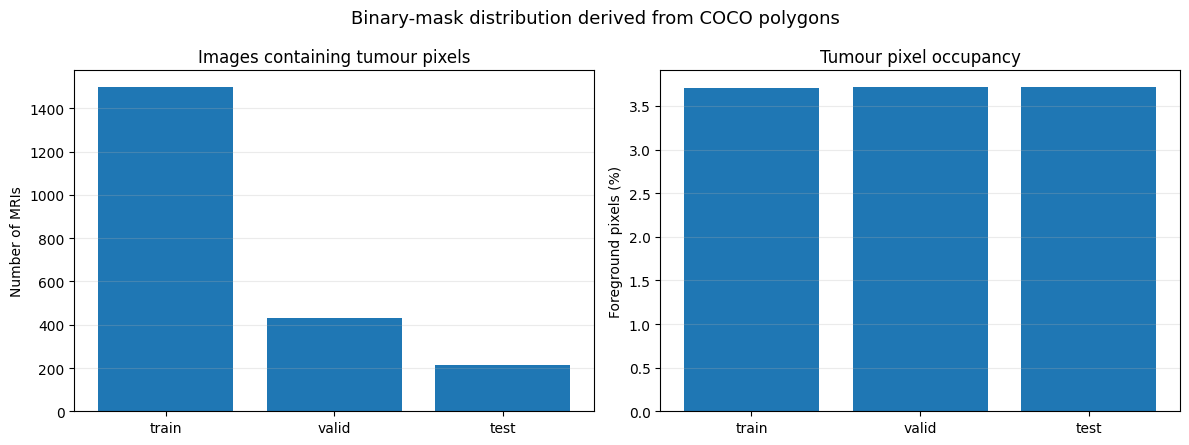

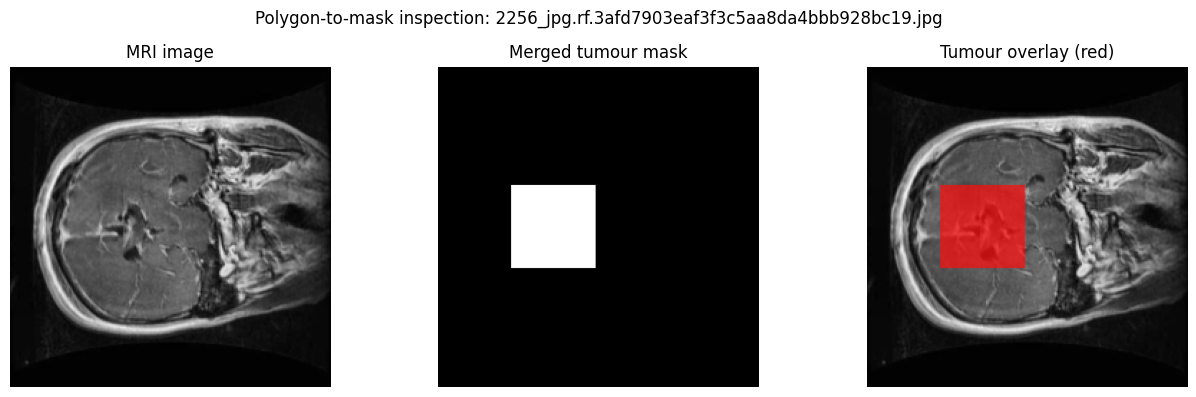

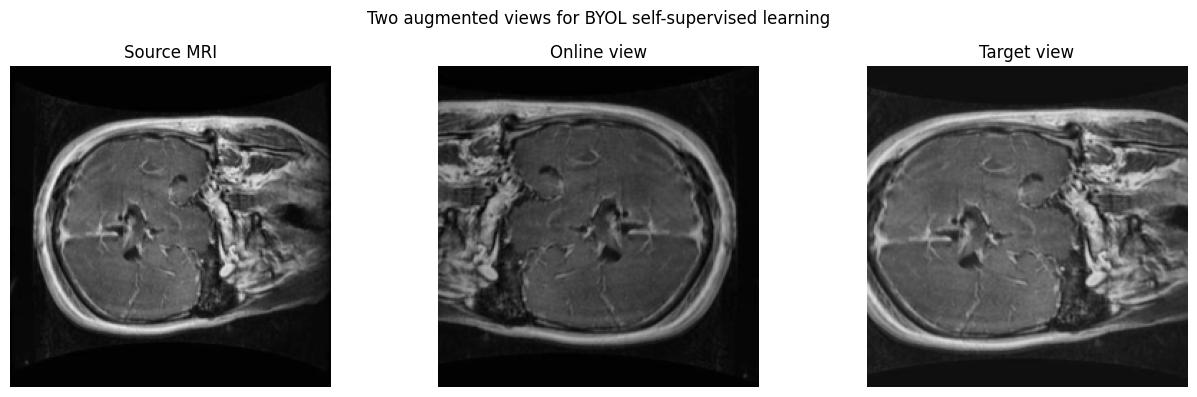

In [5]:
# ============================================================
# 5. Mask inspection and paired BYOL augmentation visualisation
# ============================================================

def undo_normalisation(tensor):
    '''Transform a model input tensor back into an RGB image for display.'''
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor.detach().cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()

def make_visible_overlay(image_array, mask_array, colour=(1.0, 0.05, 0.05), alpha=0.72):
    '''Colour only the foreground pixels so that small tumour regions remain visible.'''
    overlay = image_array.copy()
    region = np.asarray(mask_array).astype(bool)
    if region.any():
        colour_array = np.asarray(colour, dtype=np.float32)
        overlay[region] = (1.0 - alpha) * overlay[region] + alpha * colour_array
    return np.clip(overlay, 0.0, 1.0)

figure, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(mask_summary['split'], mask_summary['images_with_tumour'])
axes[0].set_title('Images containing tumour pixels')
axes[0].set_ylabel('Number of MRIs')
axes[0].grid(axis='y', alpha=0.25)
axes[1].bar(mask_summary['split'], mask_summary['foreground_pixel_percentage'])
axes[1].set_title('Tumour pixel occupancy')
axes[1].set_ylabel('Foreground pixels (%)')
axes[1].grid(axis='y', alpha=0.25)
figure.suptitle('Binary-mask distribution derived from COCO polygons', fontsize=13)
figure.tight_layout()
figure.savefig(FIGURE_DIR / '01_mask_distribution.png', dpi=180, bbox_inches='tight')
plt.show()

positive_index = next(
    (index for index in range(len(train_display_dataset))
     if train_display_dataset[index][1].sum().item() > 0), 0
)
image, mask, file_name = train_display_dataset[positive_index]
image_array = undo_normalisation(image)
mask_array = mask.numpy()
overlay_array = make_visible_overlay(image_array, mask_array)

figure, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(image_array); axes[0].set_title('MRI image')
axes[1].imshow(mask_array, cmap='gray', vmin=0, vmax=1); axes[1].set_title('Merged tumour mask')
axes[2].imshow(overlay_array); axes[2].set_title('Tumour overlay (red)')
for axis in axes:
    axis.axis('off')
figure.suptitle(f'Polygon-to-mask inspection: {file_name}', fontsize=12)
figure.tight_layout()
figure.savefig(FIGURE_DIR / '02_polygon_mask_overlay.png', dpi=180, bbox_inches='tight')
plt.show()

view_one, view_two = byol_dataset[positive_index]
figure, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(image_array); axes[0].set_title('Source MRI')
axes[1].imshow(undo_normalisation(view_one)); axes[1].set_title('Online view')
axes[2].imshow(undo_normalisation(view_two)); axes[2].set_title('Target view')
for axis in axes:
    axis.axis('off')
figure.suptitle('Two augmented views for BYOL self-supervised learning', fontsize=12)
figure.tight_layout()
figure.savefig(FIGURE_DIR / '03_byol_paired_views.png', dpi=180, bbox_inches='tight')
plt.show()

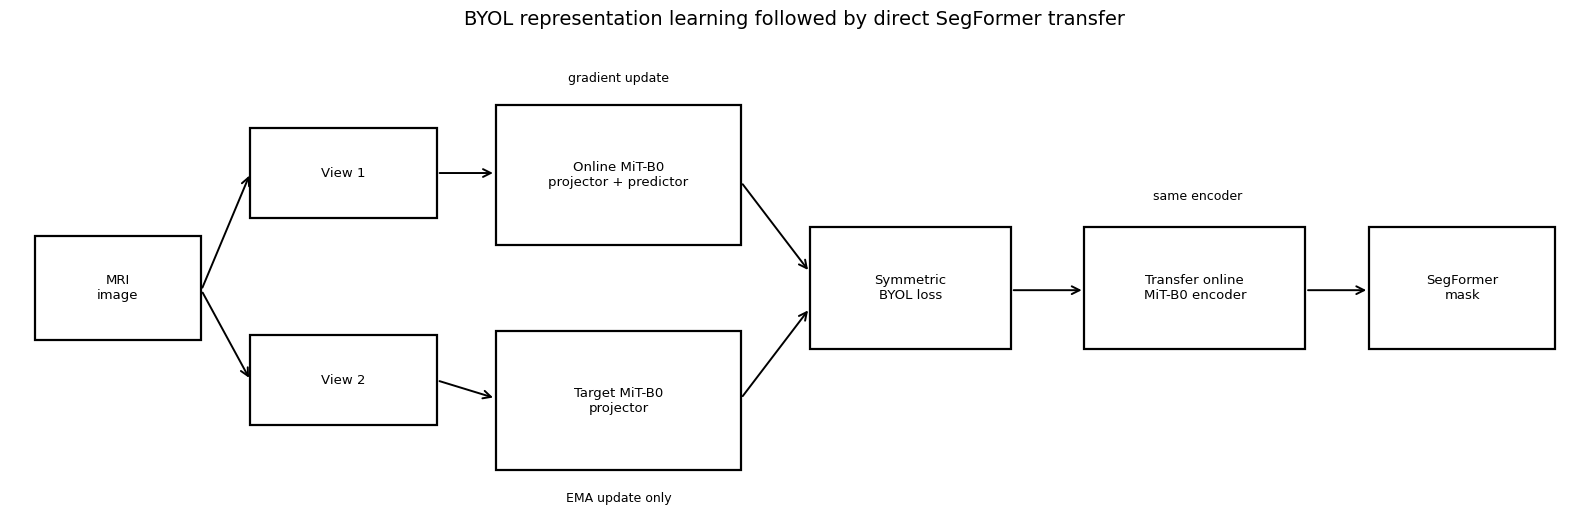

In [6]:
# ============================================================
# 6. Instructional workflow diagram: BYOL to SegFormer-B0
# ============================================================

figure, axis = plt.subplots(figsize=(16, 5.4))
axis.set_xlim(0, 16)
axis.set_ylim(0, 5.4)
axis.axis('off')

blocks = [
    (0.25, 2.0, 1.7, 1.15, 'MRI\nimage'),
    (2.45, 3.35, 1.9, 1.0, 'View 1'),
    (2.45, 1.05, 1.9, 1.0, 'View 2'),
    (4.95, 3.05, 2.5, 1.55, 'Online MiT-B0\nprojector + predictor'),
    (4.95, 0.55, 2.5, 1.55, 'Target MiT-B0\nprojector'),
    (8.15, 1.9, 2.05, 1.35, 'Symmetric\nBYOL loss'),
    (10.95, 1.9, 2.25, 1.35, 'Transfer online\nMiT-B0 encoder'),
    (13.85, 1.9, 1.9, 1.35, 'SegFormer\nmask'),
]
for x, y, width, height, label in blocks:
    axis.add_patch(Rectangle((x, y), width, height, fill=False, linewidth=1.6))
    axis.text(x + width / 2, y + height / 2, label, ha='center', va='center', fontsize=9.5)

connections = [
    ((1.95, 2.55), (2.45, 3.85)), ((1.95, 2.55), (2.45, 1.55)),
    ((4.35, 3.85), (4.95, 3.85)), ((4.35, 1.55), (4.95, 1.35)),
    ((7.45, 3.75), (8.15, 2.75)), ((7.45, 1.35), (8.15, 2.35)),
    ((10.20, 2.55), (10.95, 2.55)), ((13.20, 2.55), (13.85, 2.55)),
]
for start, end in connections:
    axis.add_patch(FancyArrowPatch(start, end, arrowstyle='->', mutation_scale=14, linewidth=1.4))

axis.text(6.2, 4.86, 'gradient update', ha='center', fontsize=9)
axis.text(6.2, 0.20, 'EMA update only', ha='center', fontsize=9)
axis.text(12.1, 3.55, 'same encoder', ha='center', fontsize=9)
axis.set_title('BYOL representation learning followed by direct SegFormer transfer', fontsize=14)
figure.tight_layout()
figure.savefig(FIGURE_DIR / '04_byol_segformer_workflow.png', dpi=180, bbox_inches='tight')
plt.show()

In [7]:
# ============================================================
# 7. SegFormer MiT-B0 encoder construction with Kaggle fallback
# ============================================================

def mit_b0_fallback_config(num_labels=NUM_CLASSES):
    '''Instantiate the MiT-B0 architecture if downloaded weights are unavailable.'''
    return SegformerConfig(
        num_channels=3,
        num_encoder_blocks=4,
        depths=[2, 2, 2, 2],
        sr_ratios=[8, 4, 2, 1],
        hidden_sizes=[32, 64, 160, 256],
        patch_sizes=[7, 3, 3, 3],
        strides=[4, 2, 2, 2],
        num_attention_heads=[1, 2, 5, 8],
        mlp_ratios=[4, 4, 4, 4],
        decoder_hidden_size=256,
        num_labels=num_labels,
        semantic_loss_ignore_index=255,
        id2label={0: 'background', 1: 'tumour'},
        label2id={'background': 0, 'tumour': 1},
    )

def create_initial_mit_encoder():
    '''Load nvidia/mit-b0 when reachable; otherwise use its random architecture.'''
    if LOAD_PRETRAINED_MIT_WHEN_AVAILABLE:
        try:
            encoder = SegformerModel.from_pretrained(MIT_MODEL_ID)
            print(f'Loaded pretrained encoder: {MIT_MODEL_ID}')
            return encoder, 'pretrained nvidia/mit-b0'
        except Exception as error:
            print(f'Pretrained MiT-B0 unavailable: {type(error).__name__}: {error}')
            print('Using randomly initialised MiT-B0 for BYOL pretraining.')
    return SegformerModel(mit_b0_fallback_config()), 'randomly initialised MiT-B0'

def final_feature_map(segformer_backbone, images):
    '''Extract the final spatial MiT representation for pooling or response mapping.'''
    output = segformer_backbone(pixel_values=images, return_dict=True)
    feature = output.last_hidden_state
    if feature.ndim == 4:
        return feature
    if feature.ndim == 3:
        batch_size, token_count, channels = feature.shape
        side = int(round(math.sqrt(token_count)))
        if side * side != token_count:
            raise RuntimeError('Final token sequence could not be reshaped to a spatial grid.')
        return feature.transpose(1, 2).reshape(batch_size, channels, side, side)
    raise RuntimeError(f'Unsupported final feature shape: {tuple(feature.shape)}')

def pooled_features(segformer_backbone, images):
    '''Pool the spatial encoder output into one feature vector per MRI.'''
    return F.adaptive_avg_pool2d(final_feature_map(segformer_backbone, images), 1).flatten(1)

In [8]:
# ============================================================
# 8. BYOL model with the MiT-B0 encoder and float32 loss
# ============================================================

class ProjectionMLP(nn.Module):
    '''Projection head shared in design by online and target branches.'''
    def __init__(self, input_dim, hidden_dim=BYOL_HIDDEN_DIM, output_dim=BYOL_PROJECTION_DIM):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim, bias=False),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, output_dim, bias=False),
            nn.BatchNorm1d(output_dim, affine=False),
        )

    def forward(self, feature_vector):
        return self.network(feature_vector)

class PredictionMLP(nn.Module):
    '''Prediction head used only by the gradient-optimised online branch.'''
    def __init__(self, input_dim=BYOL_PROJECTION_DIM, hidden_dim=BYOL_HIDDEN_DIM):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim, bias=False),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, input_dim),
        )

    def forward(self, projection):
        return self.network(projection)

class BYOLSegFormer(nn.Module):
    '''BYOL whose online and target representation networks are MiT-B0 encoders.'''
    def __init__(self, ema_base=BYOL_EMA_BASE):
        super().__init__()
        self.ema_base = ema_base
        self.online_encoder, self.initialisation_source = create_initial_mit_encoder()
        final_dimension = self.online_encoder.config.hidden_sizes[-1]
        self.online_projector = ProjectionMLP(final_dimension)
        self.online_predictor = PredictionMLP()

        self.target_encoder = copy.deepcopy(self.online_encoder)
        self.target_projector = copy.deepcopy(self.online_projector)
        for parameter in list(self.target_encoder.parameters()) + list(self.target_projector.parameters()):
            parameter.requires_grad = False

    def online_representation(self, images):
        features = pooled_features(self.online_encoder, images)
        return self.online_predictor(self.online_projector(features))

    @torch.no_grad()
    def target_representation(self, images):
        features = pooled_features(self.target_encoder, images)
        return self.target_projector(features)

    @torch.no_grad()
    def update_target(self, decay):
        '''EMA target update executed after an online optimiser step.''' 
        for online, target in zip(self.online_encoder.parameters(), self.target_encoder.parameters()):
            target.data.mul_(decay).add_(online.data, alpha=1.0 - decay)
        for online, target in zip(self.online_projector.parameters(), self.target_projector.parameters()):
            target.data.mul_(decay).add_(online.data, alpha=1.0 - decay)

def byol_pair_loss_float32(online_prediction, target_projection):
    '''Compute cosine regression in float32, while stopping target gradients.'''
    with float32_loss_context(online_prediction):
        online = F.normalize(online_prediction.float(), dim=1)
        target = F.normalize(target_projection.detach().float(), dim=1)
        cosine_similarity = (online * target).sum(dim=1)
        loss = (2.0 - 2.0 * cosine_similarity).mean()
    return loss, cosine_similarity.detach()

def byol_symmetric_loss(model, first_view, second_view):
    '''Evaluate the symmetric online-to-target BYOL objective.'''
    with autocast_context():
        online_first = model.online_representation(first_view)
        online_second = model.online_representation(second_view)
        with torch.no_grad():
            target_first = model.target_representation(first_view)
            target_second = model.target_representation(second_view)

    loss_one, similarity_one = byol_pair_loss_float32(online_first, target_second)
    loss_two, similarity_two = byol_pair_loss_float32(online_second, target_first)
    return 0.5 * (loss_one + loss_two), torch.cat([similarity_one, similarity_two])

In [9]:
# ============================================================
# 9. BYOL forward/backward smoke test and ten-epoch pretraining
# ============================================================

byol_model = BYOLSegFormer().to(DEVICE)
print(f'BYOL encoder initialisation: {byol_model.initialisation_source}')

# Store the initial encoder for the three-stage feature-space comparison.
initial_encoder_state = copy.deepcopy(byol_model.online_encoder.state_dict())
torch.save(initial_encoder_state, CHECKPOINT_DIR / 'initial_mit_b0_encoder.pth')

online_parameters = (
    list(byol_model.online_encoder.parameters())
    + list(byol_model.online_projector.parameters())
    + list(byol_model.online_predictor.parameters())
)
byol_optimizer = torch.optim.AdamW(online_parameters, lr=BYOL_LR, weight_decay=WEIGHT_DECAY)
byol_scaler = create_grad_scaler()

# Preserve all BYOL parameters and buffers before the diagnostic step so that
# the ten reported epochs begin from the intended initial model state.
pre_smoke_byol_state = copy.deepcopy(byol_model.state_dict())

# ------------------------------------------------------------
# Execute forward and backward once before beginning the full run.
# ------------------------------------------------------------
smoke_view_one, smoke_view_two = next(iter(byol_loader))
smoke_view_one = smoke_view_one.to(DEVICE, non_blocking=PIN_MEMORY).contiguous()
smoke_view_two = smoke_view_two.to(DEVICE, non_blocking=PIN_MEMORY).contiguous()

byol_model.train()
byol_optimizer.zero_grad(set_to_none=True)
smoke_loss, smoke_similarity = byol_symmetric_loss(byol_model, smoke_view_one, smoke_view_two)
assert smoke_loss.dtype == torch.float32, 'BYOL loss must be float32 under AMP.'
assert torch.isfinite(smoke_loss).item(), 'BYOL smoke test loss is not finite.'
byol_scaler.scale(smoke_loss).backward()
byol_scaler.step(byol_optimizer)
byol_scaler.update()
byol_model.update_target(BYOL_EMA_BASE)
print(f'BYOL forward/backward smoke test passed. Float32 loss: {smoke_loss.item():.4f}')

# Restore the pre-smoke state and a fresh optimiser so that the smoke test is
# purely diagnostic and does not introduce an unreported training update.
byol_model.load_state_dict(pre_smoke_byol_state)
byol_optimizer = torch.optim.AdamW(online_parameters, lr=BYOL_LR, weight_decay=WEIGHT_DECAY)
byol_scaler = create_grad_scaler()

# ------------------------------------------------------------
# Run ten BYOL epochs with a cosine-scheduled EMA coefficient.
# ------------------------------------------------------------
byol_history = []
total_steps = max(1, BYOL_EPOCHS * len(byol_loader))
global_step = 0

for epoch in range(1, BYOL_EPOCHS + 1):
    byol_model.train()
    epoch_losses = []
    epoch_similarities = []

    progress = tqdm(byol_loader, desc=f'BYOL epoch {epoch:02d}/{BYOL_EPOCHS}', leave=True)
    for view_one, view_two in progress:
        view_one = view_one.to(DEVICE, non_blocking=PIN_MEMORY).contiguous()
        view_two = view_two.to(DEVICE, non_blocking=PIN_MEMORY).contiguous()

        byol_optimizer.zero_grad(set_to_none=True)
        loss, similarities = byol_symmetric_loss(byol_model, view_one, view_two)
        byol_scaler.scale(loss).backward()
        byol_scaler.step(byol_optimizer)
        byol_scaler.update()

        cosine_fraction = (math.cos(math.pi * global_step / total_steps) + 1.0) / 2.0
        ema_decay = 1.0 - (1.0 - BYOL_EMA_BASE) * cosine_fraction
        byol_model.update_target(ema_decay)
        global_step += 1

        epoch_losses.append(float(loss.detach().cpu()))
        epoch_similarities.extend(similarities.float().cpu().numpy().tolist())
        progress.set_postfix(loss=f'{np.mean(epoch_losses):.4f}', similarity=f'{np.mean(epoch_similarities):.4f}')

    byol_history.append({
        'epoch': epoch,
        'byol_loss': float(np.mean(epoch_losses)),
        'paired_cosine_similarity': float(np.mean(epoch_similarities)),
        'ema_decay': float(ema_decay),
    })
    if epoch == BYOL_EPOCHS:
        final_byol_similarities = np.asarray(epoch_similarities)

byol_history_df = pd.DataFrame(byol_history)
byol_history_df.to_csv(METRIC_DIR / 'byol_pretraining_history.csv', index=False)
torch.save({
    'online_encoder': byol_model.online_encoder.state_dict(),
    'online_projector': byol_model.online_projector.state_dict(),
    'online_predictor': byol_model.online_predictor.state_dict(),
    'initialisation_source': byol_model.initialisation_source,
    'epochs': BYOL_EPOCHS,
    'ema_base': BYOL_EMA_BASE,
}, CHECKPOINT_DIR / 'byol_mit_b0_online_encoder.pth')
byol_history_df

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/14.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

SegformerModel LOAD REPORT from: nvidia/mit-b0
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded pretrained encoder: nvidia/mit-b0
BYOL encoder initialisation: pretrained nvidia/mit-b0


...

BYOL epoch 07/10:   0%|          | 0/93 [00:00<?, ?it/s]

BYOL epoch 08/10:   0%|          | 0/93 [00:00<?, ?it/s]

BYOL epoch 09/10:   0%|          | 0/93 [00:00<?, ?it/s]

BYOL epoch 10/10:   0%|          | 0/93 [00:00<?, ?it/s]

,epoch,byol_loss,paired_cosine_similarity,ema_decay
0,1,1.341405,0.329297,0.996096
1,2,0.765824,0.617088,0.996378
2,3,0.494523,0.752739,0.996819
3,4,0.350413,0.824794,0.997376
4,5,0.272580,0.863710,0.997993
5,6,0.242106,0.878947,0.998612
6,7,0.214647,0.892676,0.999170
7,8,0.199241,0.900380,0.999614
8,9,0.188425,0.905787,0.999900
9,10,0.182651,0.908674,1.000000


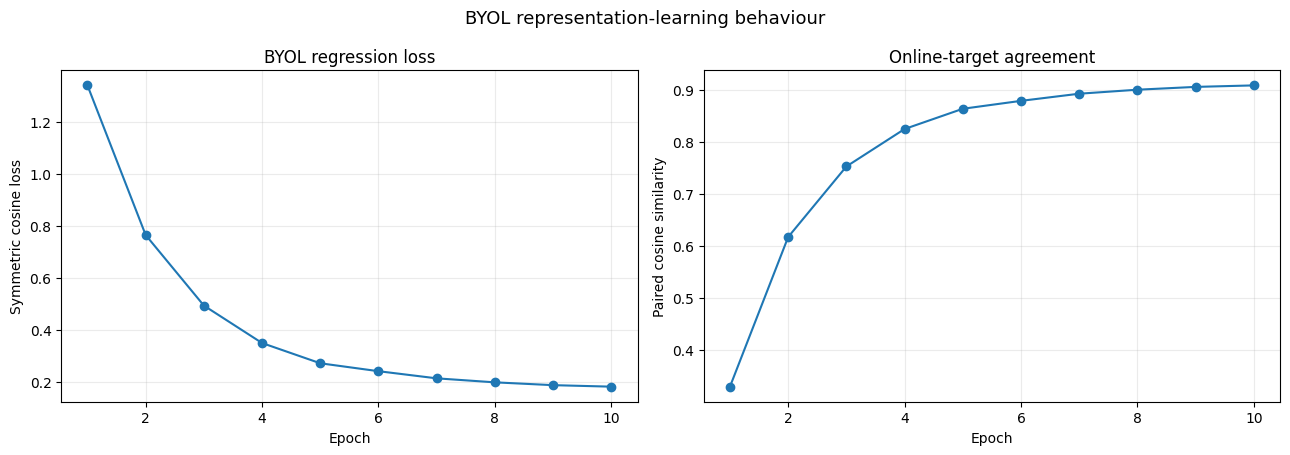

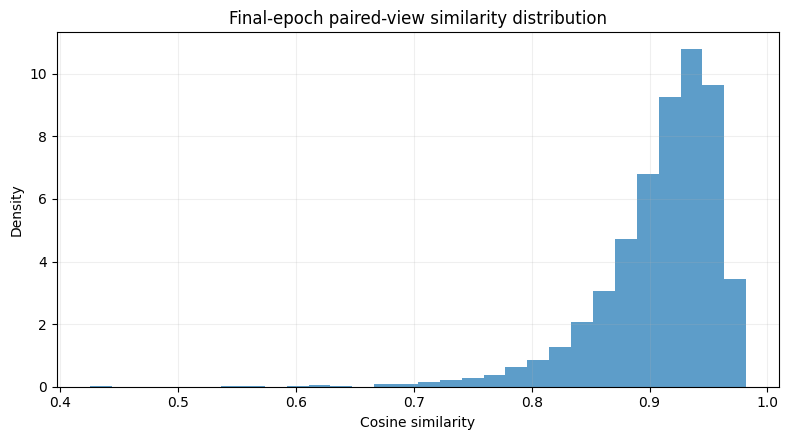

Interpretation: the online representation should become increasingly aligned with the EMA target representation for paired MRI views.


In [10]:
# ============================================================
# 10. BYOL learning diagnostics
# ============================================================

figure, axes = plt.subplots(1, 2, figsize=(13, 4.6))
axes[0].plot(byol_history_df['epoch'], byol_history_df['byol_loss'], marker='o')
axes[0].set_title('BYOL regression loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Symmetric cosine loss')
axes[0].grid(alpha=0.25)

axes[1].plot(byol_history_df['epoch'], byol_history_df['paired_cosine_similarity'], marker='o')
axes[1].set_title('Online-target agreement')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Paired cosine similarity')
axes[1].grid(alpha=0.25)
figure.suptitle('BYOL representation-learning behaviour', fontsize=13)
figure.tight_layout()
figure.savefig(FIGURE_DIR / '05_byol_training_diagnostics.png', dpi=180, bbox_inches='tight')
plt.show()

figure, axis = plt.subplots(figsize=(8, 4.5))
axis.hist(final_byol_similarities, bins=30, density=True, alpha=0.72)
axis.set_title('Final-epoch paired-view similarity distribution')
axis.set_xlabel('Cosine similarity')
axis.set_ylabel('Density')
axis.grid(alpha=0.20)
figure.tight_layout()
figure.savefig(FIGURE_DIR / '06_byol_similarity_distribution.png', dpi=180, bbox_inches='tight')
plt.show()

print('Interpretation: the online representation should become increasingly aligned with the EMA target representation for paired MRI views.')

## Direct MiT-B0 transfer and segmentation fine-tuning

The trained BYOL online encoder and the SegFormer segmentation encoder share the same MiT-B0 architecture. The learned encoder parameters are therefore transferred directly into the binary segmentation model. SegFormer produces reduced-resolution logits; the logits are upsampled bilinearly to the ground-truth mask resolution before loss and metric calculation. Cross-entropy is combined with foreground Dice loss to account for the relatively small tumour region.

In [11]:
# ============================================================
# 11. Build SegFormer-B0 and transfer the BYOL-trained encoder
# ============================================================

def build_segformer_from_byol(trained_byol):
    '''Construct a two-class SegFormer and load the same trained MiT-B0 encoder.'''
    config = copy.deepcopy(trained_byol.online_encoder.config)
    config.num_labels = NUM_CLASSES
    config.semantic_loss_ignore_index = 255
    config.id2label = {0: 'background', 1: 'tumour'}
    config.label2id = {'background': 0, 'tumour': 1}

    model = SegformerForSemanticSegmentation(config)
    transfer_report = model.segformer.encoder.load_state_dict(
        trained_byol.online_encoder.encoder.state_dict(), strict=True
    )
    print('BYOL-trained online MiT-B0 encoder transferred directly into SegFormer-B0.')
    print(transfer_report)
    return model

segmentation_model = build_segformer_from_byol(byol_model).to(DEVICE)

class CrossEntropyForegroundDiceLoss(nn.Module):
    '''Combine class-wise CE with a foreground Dice objective.'''
    def __init__(self, dice_weight=1.0, epsilon=1e-6):
        super().__init__()
        self.dice_weight = dice_weight
        self.epsilon = epsilon

    def forward(self, logits, target):
        ce_loss = F.cross_entropy(logits, target)
        foreground_probability = torch.softmax(logits.float(), dim=1)[:, 1]
        foreground_target = (target == 1).float()
        intersection = (foreground_probability * foreground_target).sum(dim=(1, 2))
        denominator = foreground_probability.sum(dim=(1, 2)) + foreground_target.sum(dim=(1, 2))
        dice = (2.0 * intersection + self.epsilon) / (denominator + self.epsilon)
        dice_loss = 1.0 - dice.mean()
        return ce_loss + self.dice_weight * dice_loss, ce_loss.detach(), dice_loss.detach()

criterion = CrossEntropyForegroundDiceLoss(dice_weight=1.0)
segmentation_optimizer = torch.optim.AdamW(segmentation_model.parameters(), lr=SEGMENTATION_LR,
                                            weight_decay=WEIGHT_DECAY)
segmentation_scaler = create_grad_scaler()

def metric_counts(prediction, target):
    '''Calculate foreground confusion components and total pixel accuracy counts.'''
    predicted_foreground = prediction == 1
    actual_foreground = target == 1
    tp = int((predicted_foreground & actual_foreground).sum().item())
    fp = int((predicted_foreground & ~actual_foreground).sum().item())
    fn = int((~predicted_foreground & actual_foreground).sum().item())
    correct = int((prediction == target).sum().item())
    total = int(target.numel())
    return tp, fp, fn, correct, total

def metrics_from_counts(tp, fp, fn, correct, total, epsilon=1e-7):
    return {
        'dice': (2.0 * tp + epsilon) / (2.0 * tp + fp + fn + epsilon),
        'iou': (tp + epsilon) / (tp + fp + fn + epsilon),
        'pixel_accuracy': correct / max(1, total),
    }

def run_segmentation_epoch(model, loader, optimizer=None, scaler=None, stage='evaluation'):
    '''Train or evaluate SegFormer with mask-resolution upsampling of logits.'''
    training = optimizer is not None
    model.train(training)
    losses = []
    tp = fp = fn = correct = total = 0

    progress = tqdm(loader, desc=stage, leave=False)
    for images, masks, _ in progress:
        images = images.to(DEVICE, non_blocking=PIN_MEMORY).contiguous()
        masks = masks.to(DEVICE, non_blocking=PIN_MEMORY).contiguous()
        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            with autocast_context():
                output = model(pixel_values=images, return_dict=True)
                logits = F.interpolate(output.logits, size=masks.shape[-2:],
                                       mode='bilinear', align_corners=False)
                loss, _, _ = criterion(logits, masks)
            if training:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

        losses.append(float(loss.detach().cpu()))
        prediction = logits.detach().argmax(dim=1)
        values = metric_counts(prediction, masks.detach())
        tp += values[0]; fp += values[1]; fn += values[2]; correct += values[3]; total += values[4]
        progress.set_postfix(loss=f'{np.mean(losses):.4f}')

    metrics = metrics_from_counts(tp, fp, fn, correct, total)
    metrics['loss'] = float(np.mean(losses))
    return metrics

BYOL-trained online MiT-B0 encoder transferred directly into SegFormer-B0.
<All keys matched successfully>


In [12]:
# ============================================================
# 12. Ten-epoch SegFormer fine-tuning and held-out evaluation
# ============================================================

segmentation_history = []
best_validation_dice = -1.0
best_checkpoint_path = CHECKPOINT_DIR / 'best_byol_segformer_binary_segmentation.pth'

for epoch in range(1, SEGMENTATION_EPOCHS + 1):
    train_metrics = run_segmentation_epoch(
        segmentation_model, train_loader, optimizer=segmentation_optimizer,
        scaler=segmentation_scaler, stage=f'SegFormer train {epoch:02d}/{SEGMENTATION_EPOCHS}'
    )
    valid_metrics = run_segmentation_epoch(
        segmentation_model, valid_loader, stage=f'SegFormer valid {epoch:02d}/{SEGMENTATION_EPOCHS}'
    )

    record = {'epoch': epoch}
    record.update({f'train_{key}': value for key, value in train_metrics.items()})
    record.update({f'valid_{key}': value for key, value in valid_metrics.items()})
    segmentation_history.append(record)

    print(
        f'Epoch {epoch:02d}: train loss={train_metrics["loss"]:.4f}, '
        f'train Dice={train_metrics["dice"]:.4f} | valid loss={valid_metrics["loss"]:.4f}, '
        f'valid Dice={valid_metrics["dice"]:.4f}, valid IoU={valid_metrics["iou"]:.4f}, '
        f'valid accuracy={valid_metrics["pixel_accuracy"]:.4f}'
    )

    if valid_metrics['dice'] > best_validation_dice:
        best_validation_dice = valid_metrics['dice']
        torch.save({
            'model_state_dict': segmentation_model.state_dict(),
            'epoch': epoch,
            'validation_metrics': valid_metrics,
            'encoder_source': 'BYOL online MiT-B0 encoder',
        }, best_checkpoint_path)

segmentation_history_df = pd.DataFrame(segmentation_history)
segmentation_history_df.to_csv(METRIC_DIR / 'segformer_training_history.csv', index=False)

best_checkpoint = torch.load(best_checkpoint_path, map_location=DEVICE)
segmentation_model.load_state_dict(best_checkpoint['model_state_dict'])
test_metrics = run_segmentation_epoch(segmentation_model, test_loader, stage='Held-out test evaluation')
test_metrics_df = pd.DataFrame([test_metrics])
test_metrics_df.to_csv(METRIC_DIR / 'test_metrics.csv', index=False)

print('\nHeld-out test performance from the best validation checkpoint')
print(test_metrics_df.round(4).to_string(index=False))
print(f'\nSaved checkpoint: {best_checkpoint_path}')

SegFormer train 01/10:   0%|          | 0/251 [00:00<?, ?it/s]

SegFormer valid 01/10:   0%|          | 0/72 [00:00<?, ?it/s]

Epoch 01: train loss=0.7266, train Dice=0.5220 | valid loss=0.4988, valid Dice=0.6245, valid IoU=0.4540, valid accuracy=0.9692


SegFormer train 02/10:   0%|          | 0/251 [00:00<?, ?it/s]

SegFormer valid 02/10:   0%|          | 0/72 [00:00<?, ?it/s]

...

SegFormer train 10/10:   0%|          | 0/251 [00:00<?, ?it/s]

SegFormer valid 10/10:   0%|          | 0/72 [00:00<?, ?it/s]

Epoch 10: train loss=0.2982, train Dice=0.7775 | valid loss=0.2927, valid Dice=0.7829, valid IoU=0.6432, valid accuracy=0.9837


Held-out test evaluation:   0%|          | 0/36 [00:00<?, ?it/s]


Held-out test performance from the best validation checkpoint
  dice    iou  pixel_accuracy   loss
0.7533 0.6042          0.9815 0.3251

Saved checkpoint: /kaggle/working/byol_segformer_brain_tumour/checkpoints/best_byol_segformer_binary_segmentation.pth


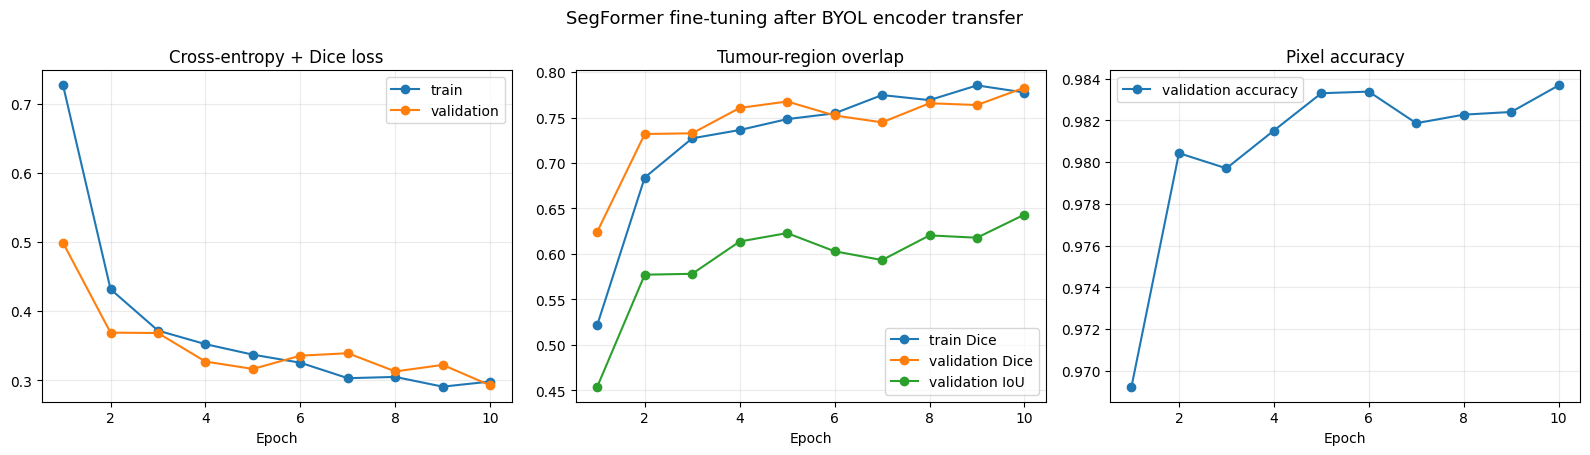

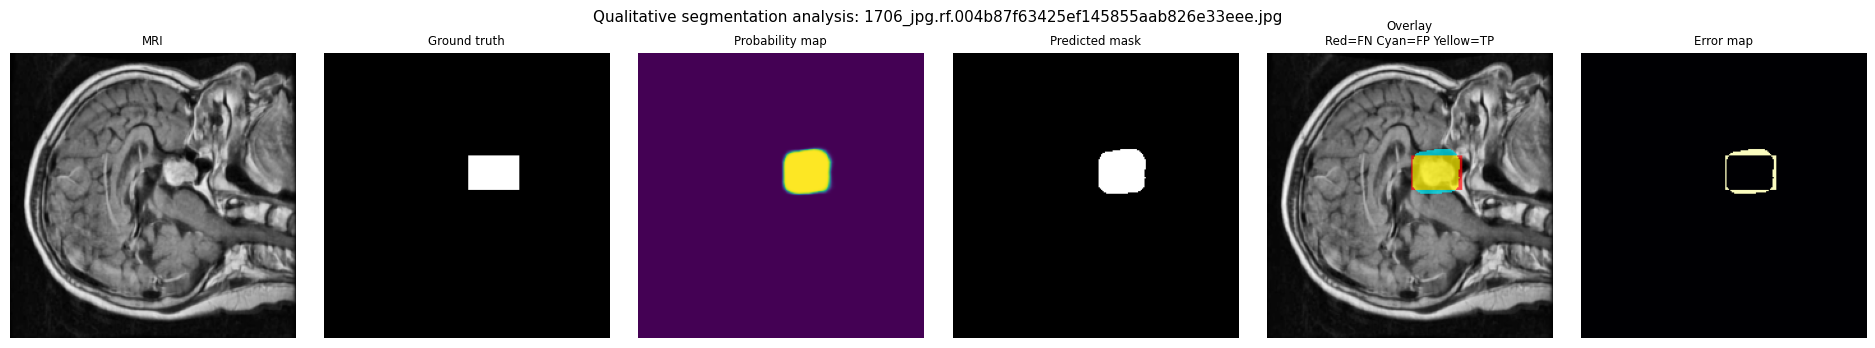

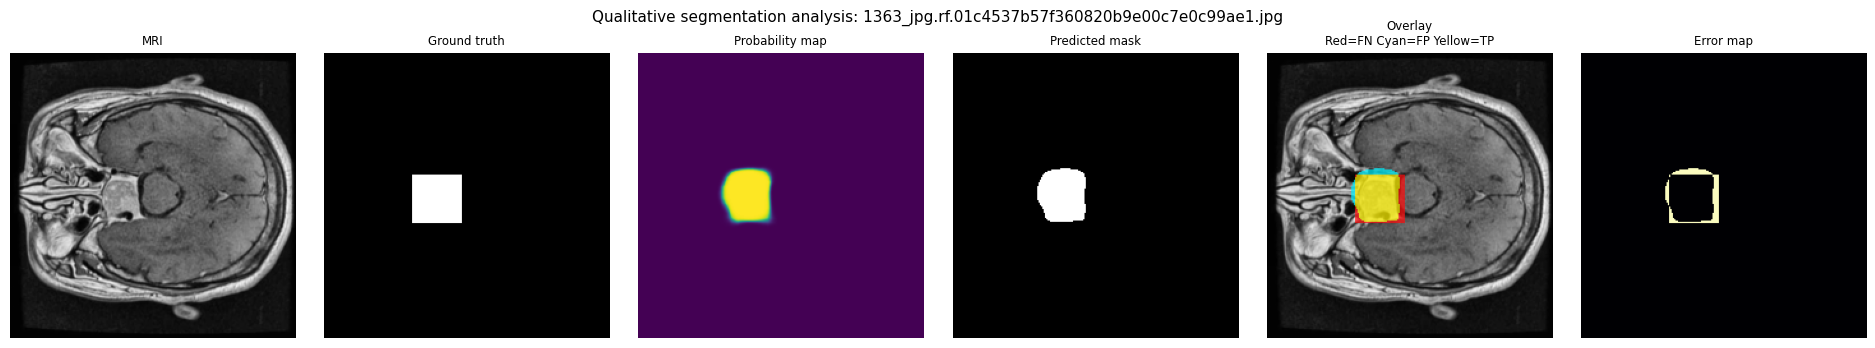

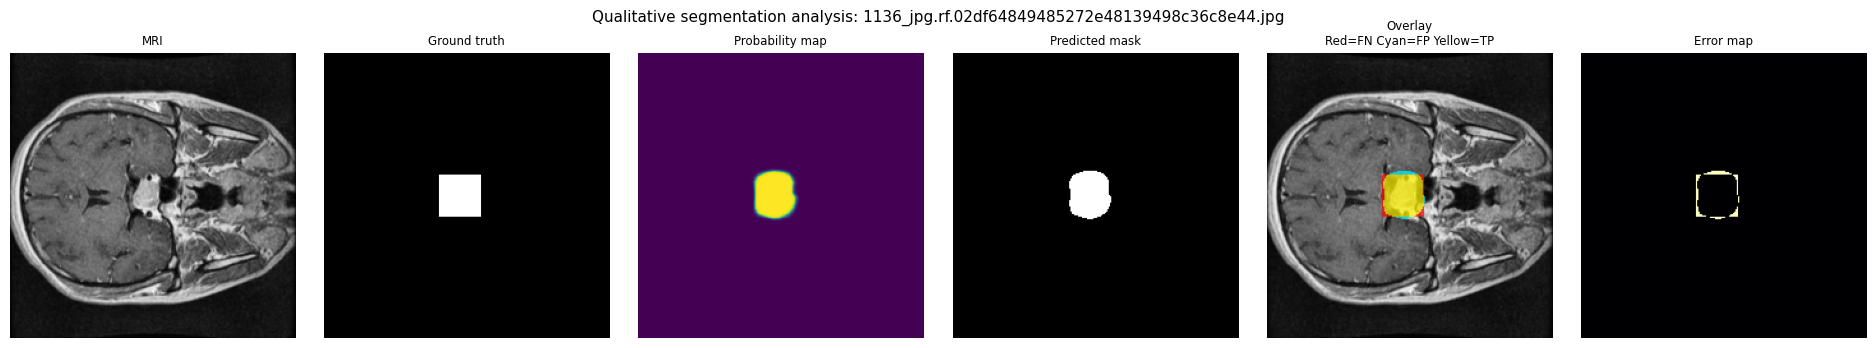

In [13]:
# ============================================================
# 13. Segmentation curves and qualitative prediction analysis
# ============================================================

figure, axes = plt.subplots(1, 3, figsize=(16, 4.6))
axes[0].plot(segmentation_history_df['epoch'], segmentation_history_df['train_loss'], marker='o', label='train')
axes[0].plot(segmentation_history_df['epoch'], segmentation_history_df['valid_loss'], marker='o', label='validation')
axes[0].set_title('Cross-entropy + Dice loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.25)
axes[1].plot(segmentation_history_df['epoch'], segmentation_history_df['train_dice'], marker='o', label='train Dice')
axes[1].plot(segmentation_history_df['epoch'], segmentation_history_df['valid_dice'], marker='o', label='validation Dice')
axes[1].plot(segmentation_history_df['epoch'], segmentation_history_df['valid_iou'], marker='o', label='validation IoU')
axes[1].set_title('Tumour-region overlap'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.25)
axes[2].plot(segmentation_history_df['epoch'], segmentation_history_df['valid_pixel_accuracy'], marker='o', label='validation accuracy')
axes[2].set_title('Pixel accuracy'); axes[2].set_xlabel('Epoch'); axes[2].legend(); axes[2].grid(alpha=0.25)
figure.suptitle('SegFormer fine-tuning after BYOL encoder transfer', fontsize=13)
figure.tight_layout()
figure.savefig(FIGURE_DIR / '07_segmentation_training_curves.png', dpi=180, bbox_inches='tight')
plt.show()

@torch.inference_mode()
def predict_sample(model, dataset, index):
    image, target, filename = dataset[index]
    batch = image.unsqueeze(0).to(DEVICE).contiguous()
    with autocast_context():
        logits = model(pixel_values=batch, return_dict=True).logits
        logits = F.interpolate(logits, size=target.shape[-2:], mode='bilinear', align_corners=False)
    probability = torch.softmax(logits.float(), dim=1)[0, 1].cpu()
    prediction = (probability >= 0.5).long()
    return image, target, probability, prediction, filename

def comparison_overlay(image_array, target_array, prediction_array, alpha=0.72):
    '''Red=False negative, cyan=False positive, yellow=True positive.''' 
    overlay = image_array.copy()
    target = np.asarray(target_array).astype(bool)
    prediction = np.asarray(prediction_array).astype(bool)
    regions = [
        (target & ~prediction, np.array([1.0, 0.05, 0.05], dtype=np.float32)),
        (~target & prediction, np.array([0.0, 0.95, 1.0], dtype=np.float32)),
        (target & prediction, np.array([1.0, 0.95, 0.0], dtype=np.float32)),
    ]
    for region, colour in regions:
        if region.any():
            overlay[region] = (1.0 - alpha) * overlay[region] + alpha * colour
    return np.clip(overlay, 0, 1)

candidate_indices = [index for index in range(len(test_dataset)) if test_dataset[index][1].sum() > 0][:3]
if not candidate_indices:
    candidate_indices = list(range(min(3, len(test_dataset))))

for example_number, index in enumerate(candidate_indices, start=1):
    image, target, probability, prediction, filename = predict_sample(segmentation_model, test_dataset, index)
    display_image = undo_normalisation(image)
    target_array = target.numpy()
    probability_array = probability.numpy()
    prediction_array = prediction.numpy()
    overlay = comparison_overlay(display_image, target_array, prediction_array)
    error_map = (prediction != target).numpy().astype(np.float32)

    figure, axes = plt.subplots(1, 6, figsize=(19, 3.5))
    panels = [
        (display_image, 'MRI', None), (target_array, 'Ground truth', 'gray'),
        (probability_array, 'Probability map', 'viridis'), (prediction_array, 'Predicted mask', 'gray'),
        (overlay, 'Overlay\nRed=FN Cyan=FP Yellow=TP', None), (error_map, 'Error map', 'magma')
    ]
    for axis, (content, title, cmap) in zip(axes, panels):
        axis.imshow(content, cmap=cmap, vmin=0 if cmap else None, vmax=1 if cmap else None)
        axis.set_title(title, fontsize=8.5); axis.axis('off')
    figure.suptitle(f'Qualitative segmentation analysis: {filename}', fontsize=11)
    figure.tight_layout()
    figure.savefig(FIGURE_DIR / f'08_prediction_example_{example_number}.png', dpi=180, bbox_inches='tight')
    plt.show()

## Feature-space and spatial-response comparison

The following analysis evaluates representations at three stages: before BYOL training, after BYOL pretraining, and after supervised SegFormer fine-tuning. Colour labels indicate whether an MRI contains tumour foreground pixels. The t-SNE plots are intended for visual interpretation of neighbourhood changes; they are not a substitute for Dice or IoU evaluation.

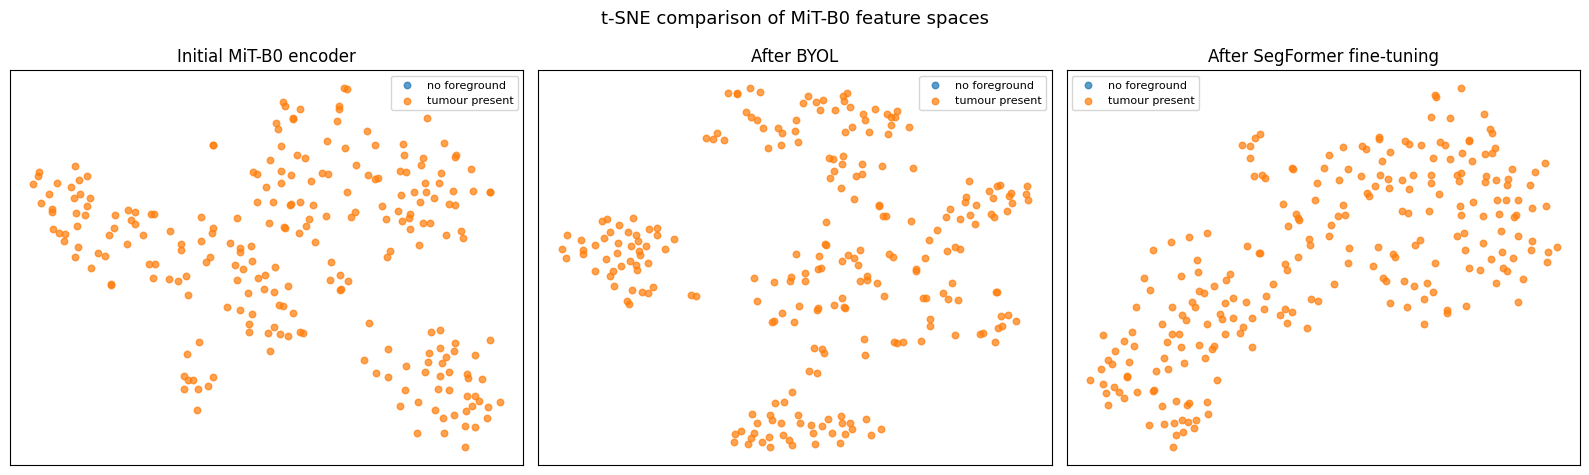

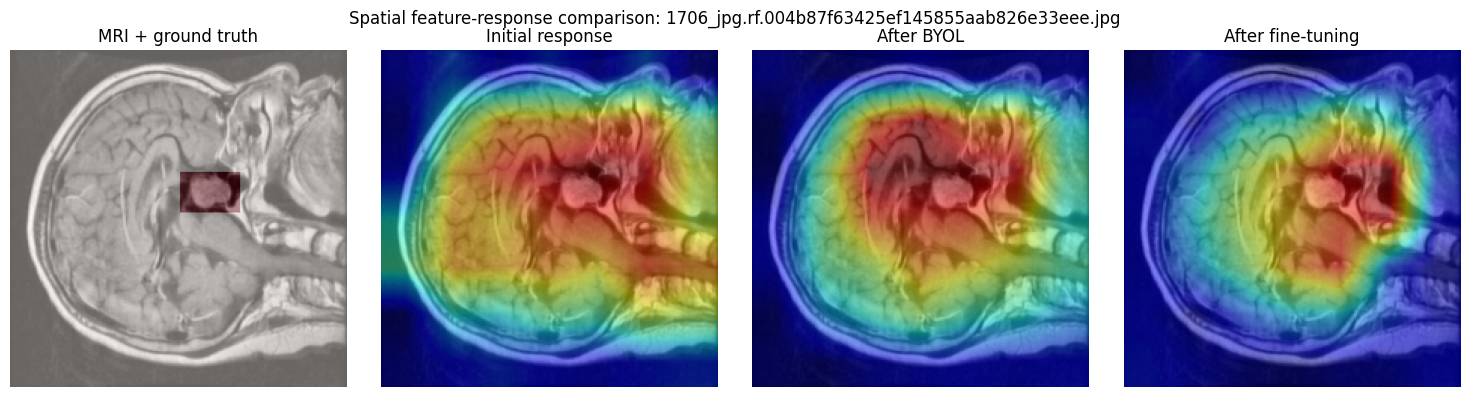

In [14]:
# ============================================================
# 14. Spatial response maps and t-SNE across three stages
# ============================================================

initial_encoder = SegformerModel(copy.deepcopy(byol_model.online_encoder.config)).to(DEVICE)
initial_encoder.load_state_dict(initial_encoder_state)
initial_encoder.eval()

byol_encoder = copy.deepcopy(byol_model.online_encoder).to(DEVICE)
byol_encoder.eval()
finetuned_encoder = segmentation_model.segformer
finetuned_encoder.eval()

@torch.inference_mode()
def collect_features(encoder, loader, maximum_samples=240):
    features, labels = [], []
    for images, masks, _ in loader:
        images = images.to(DEVICE, non_blocking=PIN_MEMORY).contiguous()
        vectors = pooled_features(encoder, images).float().cpu().numpy()
        tumour_present = (masks.flatten(1).sum(dim=1) > 0).long().numpy()
        features.append(vectors); labels.append(tumour_present)
        if sum(part.shape[0] for part in labels) >= maximum_samples:
            break
    return np.concatenate(features)[:maximum_samples], np.concatenate(labels)[:maximum_samples]

initial_features, feature_labels = collect_features(initial_encoder, feature_loader)
byol_features, _ = collect_features(byol_encoder, feature_loader)
finetuned_features, _ = collect_features(finetuned_encoder, feature_loader)

def tsne_embedding(features):
    standardised = StandardScaler().fit_transform(features)
    count = standardised.shape[0]
    perplexity = max(2, min(30, count // 4, count - 1))
    return TSNE(n_components=2, perplexity=perplexity, init='pca',
                learning_rate='auto', random_state=SEED).fit_transform(standardised)

stage_embeddings = [tsne_embedding(initial_features), tsne_embedding(byol_features), tsne_embedding(finetuned_features)]
stage_titles = ['Initial MiT-B0 encoder', 'After BYOL', 'After SegFormer fine-tuning']
figure, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for axis, embedding, title in zip(axes, stage_embeddings, stage_titles):
    for value, label in [(0, 'no foreground'), (1, 'tumour present')]:
        chosen = feature_labels == value
        axis.scatter(embedding[chosen, 0], embedding[chosen, 1], s=22, alpha=0.72, label=label)
    axis.set_title(title); axis.set_xticks([]); axis.set_yticks([]); axis.legend(fontsize=8)
figure.suptitle('t-SNE comparison of MiT-B0 feature spaces', fontsize=13)
figure.tight_layout()
figure.savefig(FIGURE_DIR / '09_tsne_three_stage_comparison.png', dpi=180, bbox_inches='tight')
plt.show()

response_index = candidate_indices[0] if candidate_indices else 0
response_image, response_mask, response_name = test_dataset[response_index]
response_batch = response_image.unsqueeze(0).to(DEVICE).contiguous()

@torch.inference_mode()
def response_map(encoder, batch, target_size):
    activation = final_feature_map(encoder, batch).float().abs().mean(dim=1, keepdim=True)
    activation = F.interpolate(activation, size=target_size, mode='bilinear', align_corners=False)[0, 0]
    activation = activation - activation.min()
    return (activation / (activation.max() + 1e-7)).cpu().numpy()

responses = [
    response_map(initial_encoder, response_batch, response_mask.shape[-2:]),
    response_map(byol_encoder, response_batch, response_mask.shape[-2:]),
    response_map(finetuned_encoder, response_batch, response_mask.shape[-2:]),
]
base_image = undo_normalisation(response_image)
figure, axes = plt.subplots(1, 4, figsize=(15, 4))
axes[0].imshow(base_image); axes[0].imshow(response_mask.numpy(), cmap='Reds', alpha=0.40, vmin=0, vmax=1)
axes[0].set_title('MRI + ground truth')
for axis, heatmap, title in zip(axes[1:], responses, ['Initial response', 'After BYOL', 'After fine-tuning']):
    axis.imshow(base_image); axis.imshow(heatmap, cmap='jet', alpha=0.48, vmin=0, vmax=1); axis.set_title(title)
for axis in axes:
    axis.axis('off')
figure.suptitle(f'Spatial feature-response comparison: {response_name}', fontsize=12)
figure.tight_layout()
figure.savefig(FIGURE_DIR / '10_spatial_response_three_stages.png', dpi=180, bbox_inches='tight')
plt.show()

In [15]:
# ============================================================
# 15. Export a concise experiment record
# ============================================================

summary = {
    'course': 'CSE 438: Digital Image Processing',
    'instructor': 'Dr Md Rifat Ahmmad Rashid',
    'pipeline': 'BYOL MiT-B0 pretraining followed by SegFormer-B0 binary segmentation',
    'dataset_root': str(DATA_ROOT),
    'classes': {'0': 'background', '1': 'tumour region'},
    'device': str(DEVICE),
    'amp_enabled': bool(AMP_ENABLED),
    'encoder_initialisation': byol_model.initialisation_source,
    'byol_epochs': BYOL_EPOCHS,
    'segmentation_epochs': SEGMENTATION_EPOCHS,
    'byol_parameters': {'projection_dimension': BYOL_PROJECTION_DIM, 'ema_base': BYOL_EMA_BASE},
    'best_validation_dice': float(best_validation_dice),
    'test_metrics': {key: float(value) for key, value in test_metrics.items()},
    'saved_outputs': {'figures': str(FIGURE_DIR), 'metrics': str(METRIC_DIR), 'checkpoints': str(CHECKPOINT_DIR)},
}
with open(OUTPUT_DIR / 'experiment_summary.json', 'w', encoding='utf-8') as file:
    json.dump(summary, file, indent=2)
print(json.dumps(summary, indent=2))
print('\nSummary comment:')
print('BYOL pretraining learns paired-view consistency using the same MiT-B0 encoder subsequently transferred into SegFormer. Interpret performance through Dice, IoU, probability maps, error-coded overlays, spatial response maps, and the feature-space comparison.')

{
  "course": "CSE 438: Digital Image Processing",
  "instructor": "Dr Md Rifat Ahmmad Rashid",
  "pipeline": "BYOL MiT-B0 pretraining followed by SegFormer-B0 binary segmentation",
  "dataset_root": "/kaggle/input/datasets/pkdarabi/brain-tumor-image-dataset-semantic-segmentation",
  "classes": {
    "0": "background",
    "1": "tumour region"
  },
  "device": "cuda",
  "amp_enabled": true,
  "encoder_initialisation": "pretrained nvidia/mit-b0",
  "byol_epochs": 10,
  "segmentation_epochs": 10,
  "byol_parameters": {
    "projection_dimension": 256,
    "ema_base": 0.996
  },
  "best_validation_dice": 0.782877792443423,
  "test_metrics": {
    "dice": 0.753281021807501,
    "iou": 0.6042107603909757,
    "pixel_accuracy": 0.9815214167062174,
    "loss": 0.3250930599040455
  },
  "saved_outputs": {
    "figures": "/kaggle/working/byol_segformer_brain_tumour/figures",
    "metrics": "/kaggle/working/byol_segformer_brain_tumour/metrics",
    "checkpoints": "/kaggle/working/byol_segformer_

## References

1. Grill, J.-B., Strub, F., Altché, F., et al. (2020). *Bootstrap Your Own Latent: A New Approach to Self-Supervised Learning*. Advances in Neural Information Processing Systems, 33, 21271–21284.  
2. Xie, E., Wang, W., Yu, Z., Anandkumar, A., Alvarez, J. M., and Luo, P. (2021). *SegFormer: Simple and Efficient Design for Semantic Segmentation with Transformers*. Advances in Neural Information Processing Systems, 34, 12077–12090.